In [5]:
pip install pandas matplotlib numpy datascience

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
# Load the southwest precipitation data
df = pd.read_csv('southwest-1.csv')

# Filter data for year 1960
data_1960 = df[df['Year'] == 1960]

# Calculate average precipitation in 1960
avg_precipitation_1960 = data_1960['Total Precipitation'].mean()
print(avg_precipitation_1960)

11.506153846153847


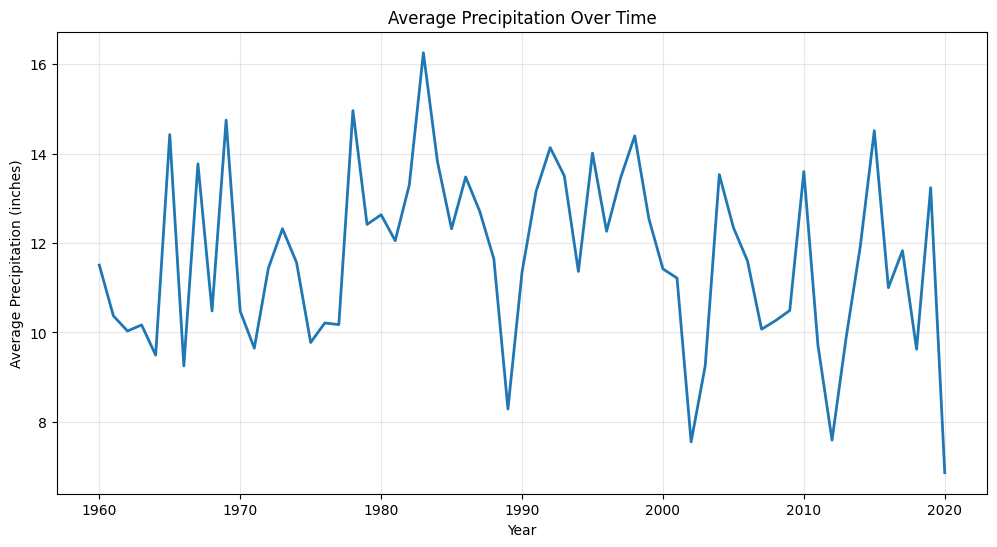

In [8]:
# Calculate average precipitation by year
avg_by_year = df.groupby('Year')['Total Precipitation'].mean()

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(avg_by_year.index, avg_by_year.values, linewidth=2)
plt.xlabel('Year')
plt.ylabel('Average Precipitation (inches)')
plt.title('Average Precipitation Over Time')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
precip_1960 = avg_by_year.loc[1960]
precip_1961 = avg_by_year.loc[1961]

pct_change = ((precip_1961 - precip_1960) / precip_1960) * 100
print(f"Percentage change from 1960 to 1961: {pct_change:.2f}%")

Percentage change from 1960 to 1961: -9.87%


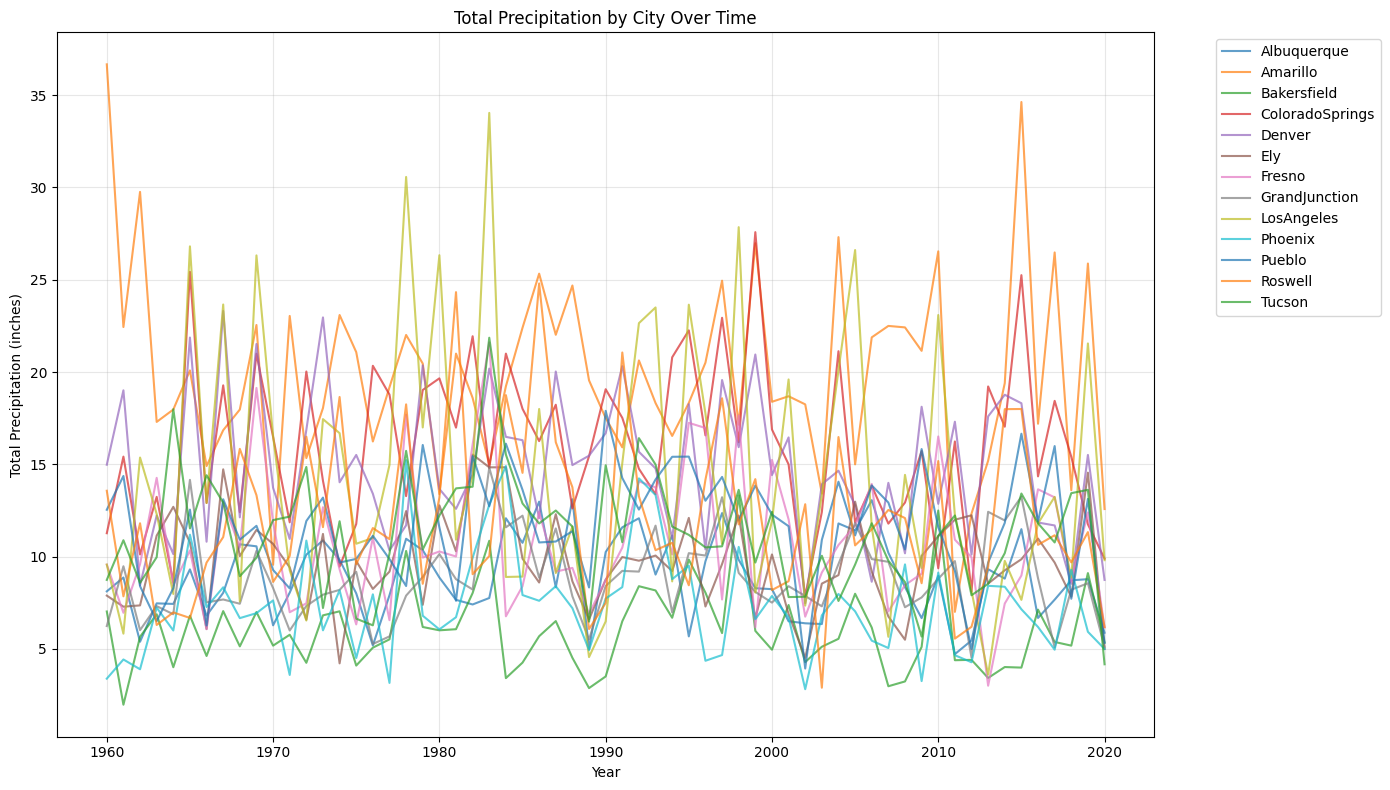

In [10]:
# Create a plot of total precipitation over time by city
plt.figure(figsize=(14, 8))

for city in df['City'].unique():
    city_data = df[df['City'] == city]
    plt.plot(city_data['Year'], city_data['Total Precipitation'], label=city, alpha=0.7)

plt.xlabel('Year')
plt.ylabel('Total Precipitation (inches)')
plt.title('Total Precipitation by City Over Time')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Define drought_label function
def drought_label(year):
    """
    Classify a year as either 'drought' or 'other' based on EPA drought periods.
    Drought years: 2002-2005 and 2012-2020
    """
    if (2002 <= year <= 2005) or (2012 <= year <= 2020):
        return 'drought'
    else:
        return 'other'

# Add drought labels to the dataframe
df['Drought'] = df['Year'].apply(drought_label)

In [11]:
# One row per year: drought label + total precipitation across all 13 cities
drought = (
    df.groupby("Year", as_index=False)
      .agg(
          Label=("Drought", "first"),
          Precipitation=("Total Precipitation", "sum")
      )
)

drought

,Year,Label,Precipitation
0,1960,other,149.58
1,1961,other,134.82
2,1962,other,130.41
3,1963,other,132.18
4,1964,other,123.41
...,...,...,...
56,2016,drought,143.02
57,2017,drought,153.75
58,2018,drought,125.13
59,2019,drought,172.10


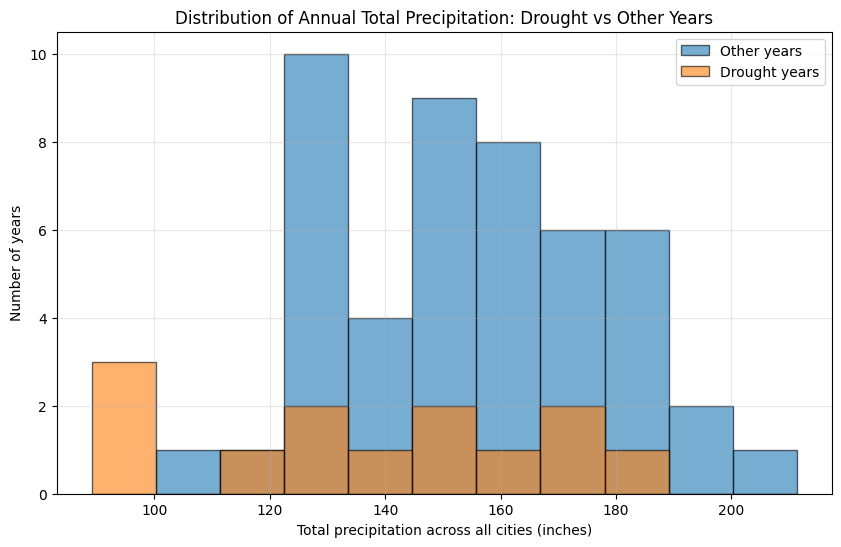

In [12]:
# Overlaid histogram: annual total precipitation in drought vs other years
drought_precip = drought.loc[drought["Label"] == "drought", "Precipitation"]
other_precip = drought.loc[drought["Label"] == "other", "Precipitation"]

bins = np.linspace(drought["Precipitation"].min(), drought["Precipitation"].max(), 12)

plt.figure(figsize=(10, 6))
plt.hist(other_precip, bins=bins, alpha=0.6, label="Other years", edgecolor="black")
plt.hist(drought_precip, bins=bins, alpha=0.6, label="Drought years", edgecolor="black")

plt.xlabel("Total precipitation across all cities (inches)")
plt.ylabel("Number of years")
plt.title("Distribution of Annual Total Precipitation: Drought vs Other Years")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Count labels in the drought table
label_counts = drought["Label"].str.lower().value_counts()

drought_count = label_counts.get("drought", 0)  # likely intended label

print(f'Count of "drought": {drought_count}')

Count of "drought": 13


In [16]:
def test_statistic(table):
    drought_mean = table.loc[table["Label"].str.lower() == "drought", "Precipitation"].mean()
    other_mean = table.loc[table["Label"].str.lower() == "other", "Precipitation"].mean()
    return drought_mean - other_mean

observed_statistic = test_statistic(drought)
print(observed_statistic)

-15.856714743589748


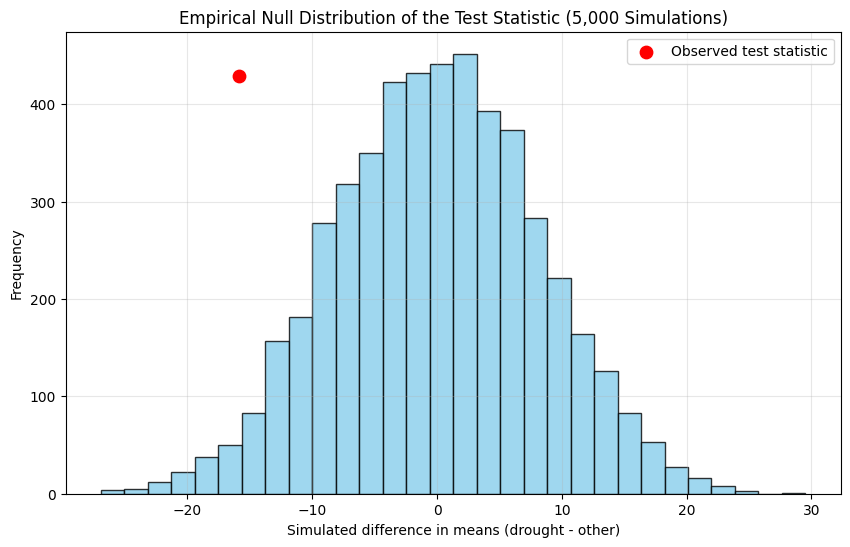

In [17]:
# Simulate the test statistic under the null hypothesis by shuffling group labels
def simulate_test_statistic_null(table):
    shuffled = table.copy()
    shuffled["Label"] = np.random.permutation(shuffled["Label"].values)
    return test_statistic(shuffled)

# Generate 5,000 simulated statistics
null_stats = np.array([simulate_test_statistic_null(drought) for _ in range(5000)])

# Plot empirical null distribution with observed statistic marked as a red dot
plt.figure(figsize=(10, 6))
counts, _, _ = plt.hist(null_stats, bins=30, color="skyblue", edgecolor="black", alpha=0.8)

y_dot = counts.max() * 0.95
plt.scatter(observed_statistic, y_dot, color="red", s=80, zorder=5, label="Observed test statistic")

plt.xlabel("Simulated difference in means (drought - other)")
plt.ylabel("Frequency")
plt.title("Empirical Null Distribution of the Test Statistic (5,000 Simulations)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# One-sided p-value for alternative: drought years have lower precipitation than other years
precipitation_p_val = np.mean(null_stats <= observed_statistic)

print(f"The p-value is about {precipitation_p_val:.2f}")

The p-value is about 0.03
